# Modelo de Ising: *Geometría triangular*

### Joshua Briones Andrade

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import itertools
from numba import jit
from numba import njit
import time

### Tipo de geometría 

In [2]:
"""
g=0 para geometría triangular simple
g=1 para geometría hexagonal
"""
g=0

################

geom = [[np.matrix([[0, 1, 1],
                    [1, 0, 1],
                    [1, 1, 0]])],
        [np.matrix([[0, 0, 1],
                    [1, 0, 1]]), 
         np.matrix([[1, 0, 0],
                    [1, 0, 1]])]]

filtros = geom[g]
filtros

[matrix([[0, 1, 1],
         [1, 0, 1],
         [1, 1, 0]])]

### Primeros vecinos

In [29]:
def matriz_prueba(N):
# lista = np.array([random.choice([-1, 1]) for n in range(N**2)])
    lista = np.array([n for n in range(N**2)])
    return lista.reshape(N,N)

N=3
mp = matriz_prueba(N)
mp

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [26]:
# @jit
def matriz_aumentada(m):
    N = len(m)
    temp_list = np.zeros((N+2, N+2)); 
    
    temp_list[0][0] = m[N-1,N-1] +1
    temp_list[0][1:N+1] = m[N-1] +1
    temp_list[0][N+1] = m[N-1,0] +1
    for i in range(N):
        temp_list[i+1][0] = m[i,N-1] +1
        temp_list[i+1][1:N+1] = m[i] +1
        temp_list[i+1][N+1] = m[i,0] +1
        
    temp_list[N+1][0] = m[0,N-1] +1
    temp_list[N+1][1:N+1] = m[0] +1
    temp_list[N+1][N+1] = m[0,0] +1
    return temp_list.astype(int)

# start = time.time()        
m_a= matriz_aumentada(mp)
m_a


array([[9, 7, 8, 9, 7],
       [3, 1, 2, 3, 1],
       [6, 4, 5, 6, 4],
       [9, 7, 8, 9, 7],
       [3, 1, 2, 3, 1]])

In [27]:
def arreglo_vecinos(m, N):
    m_a = matriz_aumentada(m)
    l = len(filtros[0])
    temp_list = []; 

    for i in np.arange(N**2):
        j = (i-(i)%N)//N;
        k = i%N;
        lista = np.multiply(m_a[j:j+l,k:k+l], filtros).flatten()
#         print(m_a[j:j+l,k:k+l],j,k)
        arreglo = np.setdiff1d(lista, 0)
        temp_list.append(arreglo)
    return np.matrix(temp_list)-1

arreglo_vecinos(mp, N)

matrix([[1, 2, 3, 5, 6, 7],
        [0, 2, 3, 4, 7, 8],
        [0, 1, 4, 5, 6, 8],
        [0, 1, 4, 5, 6, 8],
        [1, 2, 3, 5, 6, 7],
        [0, 2, 3, 4, 7, 8],
        [0, 2, 3, 4, 7, 8],
        [0, 1, 4, 5, 6, 8],
        [1, 2, 3, 5, 6, 7]])

## Configuración de espines

In [6]:
N = 65;

C_f1 = np.ones(N**2, dtype=int) #configuración fría
C_f2 = np.ones(N**2, dtype=int)*(-1) #configuración fría
C_c = np.array([random.choice([-1, 1]) for n in range(N**2)]) #configuración caliente

vecinos = arreglo_vecinos(matriz_prueba(N), N)

vecinos[1], C_f1

(matrix([[   0,    2,   65,   66, 4161, 4162]]),
 array([1, 1, 1, ..., 1, 1, 1]))

### Energía individual

In [7]:
J = 2;

@jit
def energia_u(C, N, vecinos, indice=None):
    if indice==None:
        pass
    else:
        s = 0;
        for i in np.arange(vecinos.shape[1]):
#             print(C[vecinos[indice,i-1]])
            s += C[vecinos[indice,i-1]]*C[indice]
    return -J*s

energia_u(C_f1, N, vecinos, indice=1)

-12

In [8]:
J = 2;

energia_u(C_f1, N, vecinos, indice=1)

-12

### Energía de la configuración

In [9]:
@jit
def energia(C, N, vecinos):
    s = 0;
    for i in np.arange(N**2):
        s += energia_u(C, N, vecinos, indice=i)
    return s
        
energia(C_f1, N, vecinos)/N**2

-12.0

### Magnetización del sistema

In [10]:
@jit
def mag_p(C, N):
    return np.sum(C)/N**2

mag_p(C_f1, N)

1.0

## Metropolis - Montecarlo

In [11]:
@jit
def cambiar_spin(C, N, vecinos, K=1):
    e = 0; C2 = np.copy(C)
    
    for k in np.arange(K):
        indice = np.random.randint(N**2)
        e += - 4 * energia_u(C, N, vecinos, indice=indice)
        C2[indice] *= -1
    return C2, e

cambiar_spin(C_c, N, vecinos)

(array([ 1, -1, -1, ..., -1,  1,  1]), -16)

In [12]:
T = 1.5;
K_B = 1;

@jit
def aceptar_cambio(C, N, vecinos, T, K=1):
    C2, e = cambiar_spin(C, N, vecinos, K=K)
    
    t0 = np.exp(-e/(K_B*T))
    t1 = np.random.uniform(0,1)
    if (e<0) or (t0 > t1):
        C = C2 
    return C

aceptar_cambio(C_f1, N, vecinos, T, K=1)

array([1, 1, 1, ..., 1, 1, 1])

### Evolución del sistema

In [13]:
@jit
def evolucion(C, N, vecinos, T, M, saltos=1):
    config = np.zeros((M, N**2))
    for i in np.arange(M):
        config[i] = C
        C= aceptar_cambio(C, N, vecinos, T, K=saltos)
    return config

In [14]:
@jit
def observables(config, M, k):
    energias, mag = np.zeros(M//k), np.zeros(M//k)
    for i in np.arange(0, M//k):
        energias[i] = energia(config[i*k], N, vecinos)/N**2
        mag[i] = mag_p(config[i*k], N)
    return energias, mag

## Simulación

In [21]:
T=23; J=1/2

saltos = 1;
k = 100; M = 50000;

config1 = evolucion(C_f1, N, vecinos, T, M, saltos=saltos)
e1, mag1 = observables(config1, M, k)

config2 = evolucion(C_f2, N, vecinos, T, M, saltos=saltos)
e2, mag2 = observables(config2, M, k)

config3 = evolucion(C_c, N, vecinos, T, M, saltos=saltos)
e3, mag3 = observables(config3, M, k)

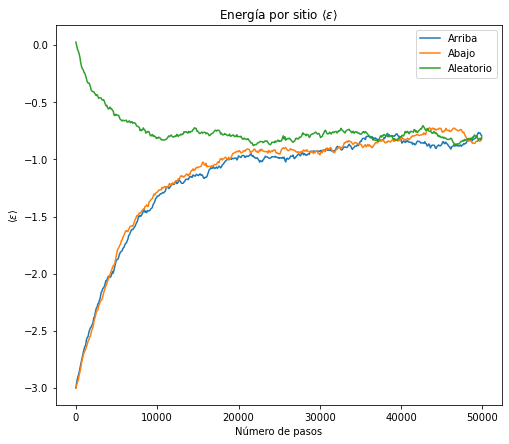

In [22]:
plt.figure(figsize=(8,7))
plt.plot(np.arange(len(e1))*k, e1, label="Arriba")
plt.plot(np.arange(len(e2))*k, e2, label="Abajo")
plt.plot(np.arange(len(e3))*k, e3,label="Aleatorio")
# plt.ylim(bottom=-2.0, top=0.0);
plt.legend();
plt.title(r"Energía por sitio $\langle \varepsilon\rangle$");  plt.ylabel(r"$\langle \varepsilon\rangle$"); plt.xlabel("Número de pasos")
plt.show()

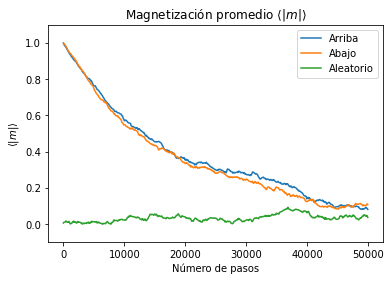

In [23]:
# plt.figure(figsize=(17,7))
plt.plot(np.arange(len(mag1))*k, np.abs(mag1), label="Arriba")
plt.plot(np.arange(len(mag2))*k, np.abs(mag2), label="Abajo")
plt.plot(np.arange(len(mag3))*k, np.abs(mag3),label="Aleatorio")
plt.ylim(bottom=-0.1, top=1.1); plt.legend();
plt.title(r"Magnetización promedio $\langle |m|\rangle$"); plt.ylabel(r"$\langle |m|\rangle$"); plt.xlabel("Número de pasos")
plt.show()

## Newton - Rapson

In [18]:
def newton(f,df,a,b,epsilon, tol=1e-10):
    dx=2*epsilon
    contador = 0
    x=0.5*(a+b)
    while dx> epsilon and contador<1000:
        x1=x-f(x)/(df(x))
        dx=abs(x-x1)
        x=x1
        contador=contador+1
        
    return x,contador

In [19]:
J = 2; K_B=1;
def f(T):
    return 2*(np.tanh(2*J/(K_B*T)))**2-1

def df(T):
    t1 = -8/((T**2)*K_B)
    t2 = np.tanh(2*J/(K_B*T))
    t3 = 1/(np.cosh(2*J/(K_B*T))**2) 
    return t1*t2*t3

Tc = newton(f,df,4,5,1e-5)[0]
Tc

4.501222550086696

<ipython-input-19-2494d13be816>:3: RuntimeWarning: divide by zero encountered in true_divide
  return 2*(np.tanh(2*J/(K_B*T)))**2-1


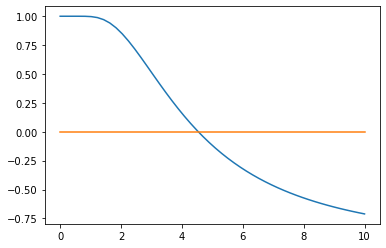

In [20]:
T = np.linspace(0,10);
plt.plot(T,f(T))
plt.plot(T,np.zeros(50))
# plt.scatter(Tc,f(Tc))
plt.show()